# 🦎 Lizard Species Classification – Kaggle Challenge

**Team:** _[vul hier jullie teamnaam in]_  
**Members:** _[naam 1]_, _[naam 2]_, _[naam 3]_  
**Date:** _[datum]_

---

## Overzicht

In dit notebook klassificeren we 7 soorten hagedissen voor de Kaggle challenge.

| Label | Soort |
|-------|-------|
| 0 | Black_spiny_tailed_iguana |
| 1 | Brown_anole |
| 2 | Cuban_knight_anole |
| 3 | Desert_iguana |
| 4 | Green_anole |
| 5 | Green_iguana |
| 6 | Lesser_Antillean_iguana |

**Dataset:**
- 1334 trainingsafbeeldingen in `train/` (7 submappen, 1 per soort)
- 326 testafbeeldingen in `test/` (genummerd: `1.jpg` t/m `326.jpg`)

**Stappen:**
1. EDA – Exploratory Data Analysis
2. Eigen CNN model (baseline)
3. Transfer Learning met EfficientNetB0 + Fine-tuning
4. Data Augmentation
5. Trainingscurves
6. Confusion Matrix & evaluatie
7. Kaggle Submission

> ⚠️ **Tip:** Voer dit notebook uit op Google Colab met GPU-runtime voor snellere training.

---
## 0. Setup & Imports

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from PIL import Image

print('TensorFlow versie:', tf.__version__)
print('GPU beschikbaar:', tf.config.list_physical_devices('GPU'))

TensorFlow versie: 2.21.0
GPU beschikbaar: []


In [13]:
# Paden
TRAIN_DIR = 'train'   # bevat 7 submappen
TEST_DIR  = 'test'    # bevat 1.jpg t/m 326.jpg

# Hyperparameters
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.2
SEED       = 42
AUTOTUNE   = tf.data.AUTOTUNE

# Klassen (alfabetisch = dezelfde volgorde als Keras inference)
CLASS_NAMES = [
    'Black_spiny_tailed_iguana',  # 0
    'Brown_anole',                # 1
    'Cuban_knight_anole',         # 2
    'Desert_iguana',              # 3
    'Green_anole',                # 4
    'Green_iguana',               # 5
    'Lesser_Antillean_iguana'     # 6
]
NUM_CLASSES = len(CLASS_NAMES)
print(f'{NUM_CLASSES} klassen geladen')

7 klassen geladen


---
## 1. EDA – Exploratory Data Analysis

In [14]:
# Aantal afbeeldingen per klasse
train_df = pd.read_csv('train.csv')
train_df['class_name'] = train_df['label'].map(dict(enumerate(CLASS_NAMES)))
counts = train_df['class_name'].value_counts().reindex(CLASS_NAMES)

print(f'Totaal trainingsafbeeldingen: {len(train_df)}')
print(counts)

Totaal trainingsafbeeldingen: 1334
class_name
Black_spiny_tailed_iguana    199
Brown_anole                  193
Cuban_knight_anole           189
Desert_iguana                183
Green_anole                  178
Green_iguana                 196
Lesser_Antillean_iguana      196
Name: count, dtype: int64


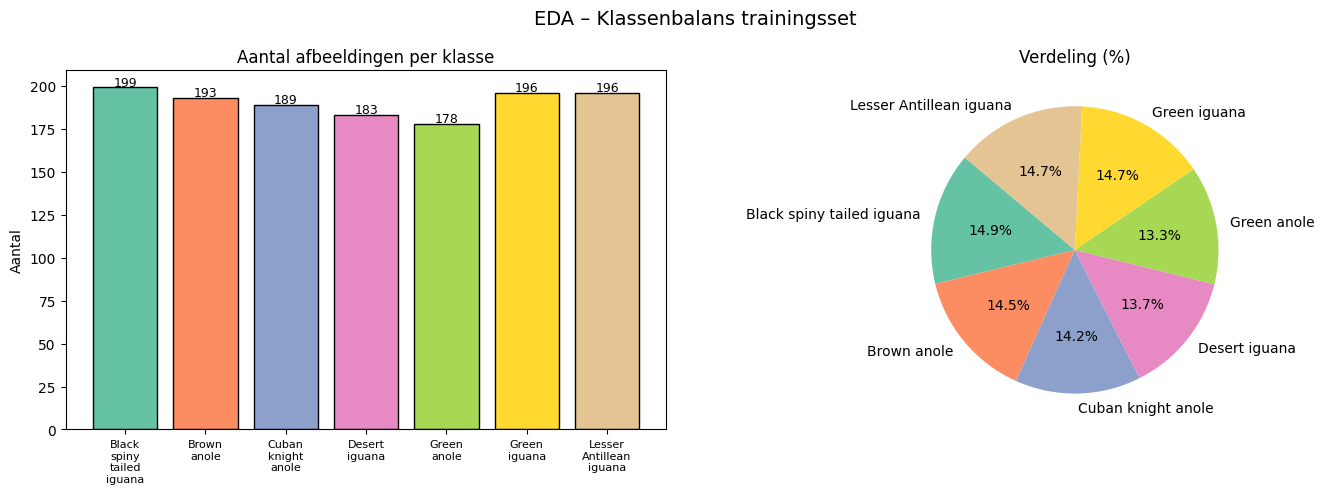

Dataset is redelijk gebalanceerd.


In [15]:
# Klassenbalans: bar + pie
colors = plt.cm.Set2.colors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(NUM_CLASSES), counts.values, color=colors, edgecolor='black')
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].set_xticklabels([c.replace('_', '\n') for c in CLASS_NAMES], fontsize=8)
axes[0].set_title('Aantal afbeeldingen per klasse')
axes[0].set_ylabel('Aantal')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=9)

axes[1].pie(counts.values, labels=[c.replace('_', ' ') for c in CLASS_NAMES],
            colors=colors, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Verdeling (%)')

plt.suptitle('EDA – Klassenbalans trainingsset', fontsize=14)
plt.tight_layout()
plt.show()

if counts.max() / counts.min() > 2:
    print('Ongebalanceerd! Overweeg class_weight.')
else:
    print('Dataset is redelijk gebalanceerd.')

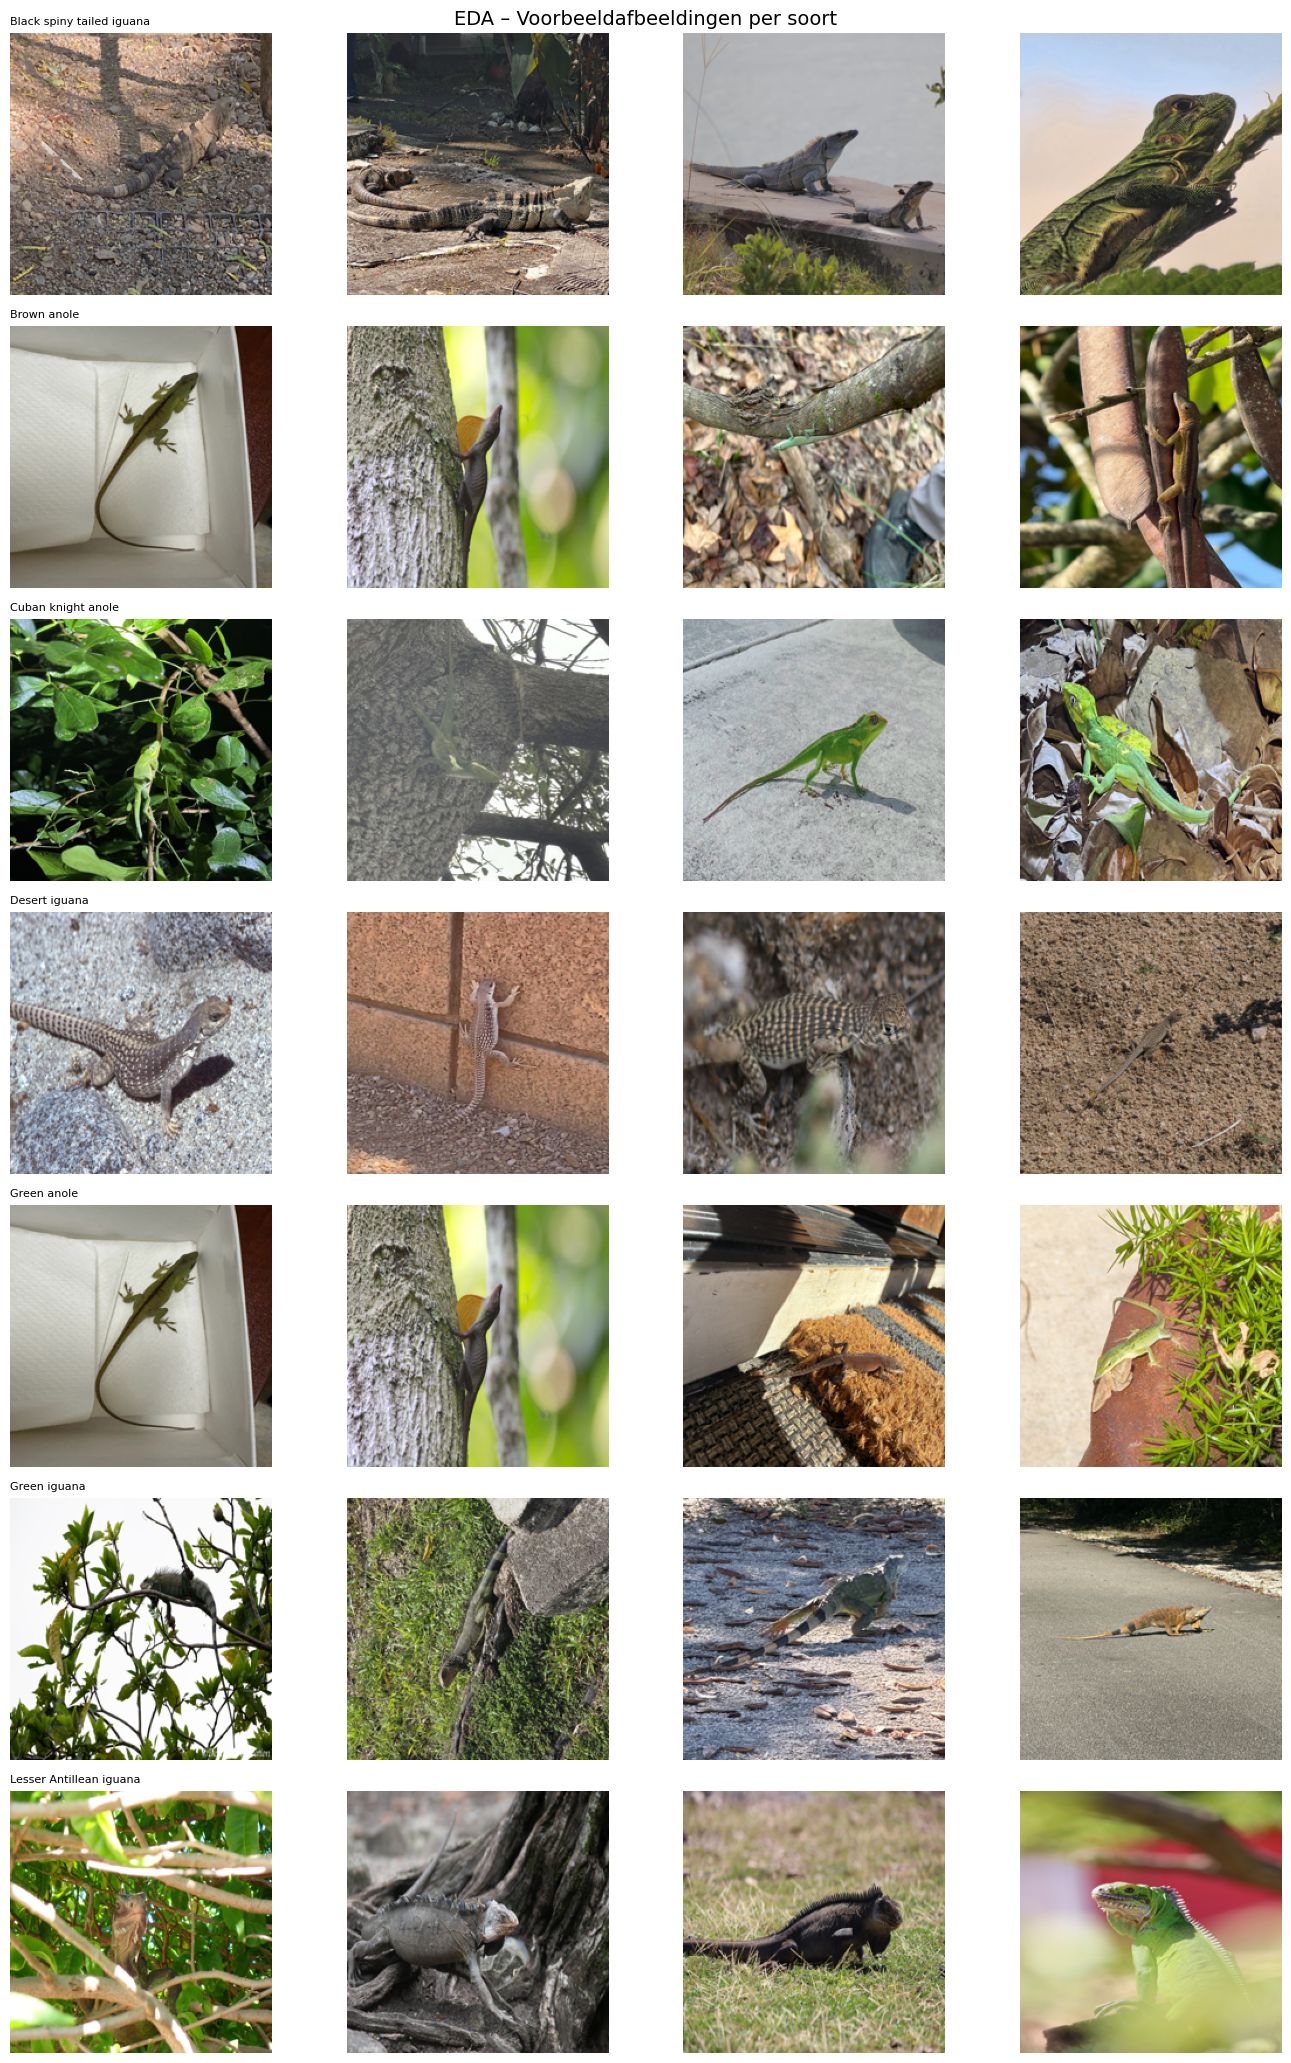

In [16]:
# Voorbeeldafbeeldingen per soort
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(14, NUM_CLASSES * 3))
for row, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs = sorted(os.listdir(cls_path))[:4]
    for col, img_name in enumerate(imgs):
        img = Image.open(os.path.join(cls_path, img_name)).resize(IMAGE_SIZE)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls.replace('_', ' '), fontsize=8, loc='left')
plt.suptitle('EDA – Voorbeeldafbeeldingen per soort', fontsize=14)
plt.tight_layout()
plt.show()

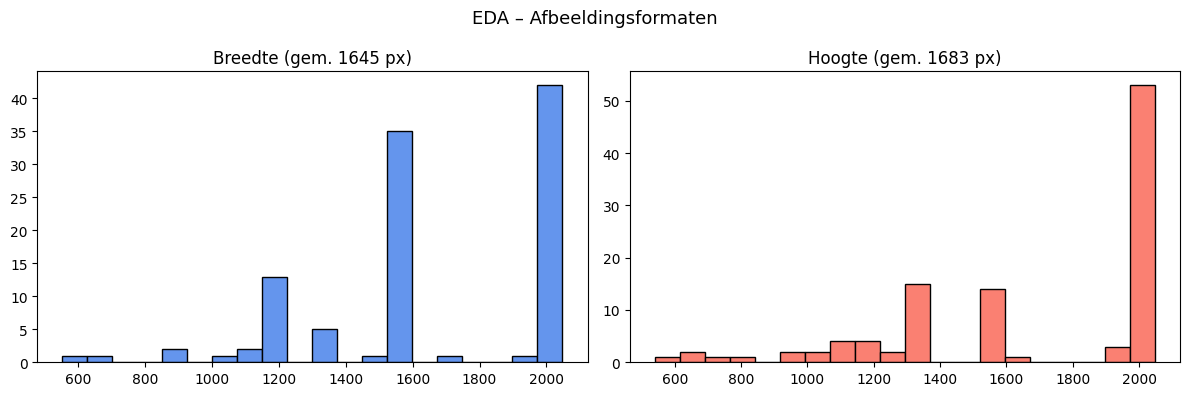

We resizen alles naar 224x224 px.


In [17]:
# Afbeeldingsgroottes (steekproef)
widths, heights = [], []
for cls in CLASS_NAMES:
    for fn in sorted(os.listdir(os.path.join(TRAIN_DIR, cls)))[:15]:
        try:
            w, h = Image.open(os.path.join(TRAIN_DIR, cls, fn)).size
            widths.append(w); heights.append(h)
        except: pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=20, color='cornflowerblue', edgecolor='black')
axes[0].set_title(f'Breedte (gem. {np.mean(widths):.0f} px)')
axes[1].hist(heights, bins=20, color='salmon',         edgecolor='black')
axes[1].set_title(f'Hoogte (gem. {np.mean(heights):.0f} px)')
plt.suptitle('EDA – Afbeeldingsformaten', fontsize=13)
plt.tight_layout()
plt.show()
print(f'We resizen alles naar {IMAGE_SIZE[0]}x{IMAGE_SIZE[1]} px.')

---
## 2. Data Laden & Data Augmentation

In [18]:
# Trainings- en validatieset vanuit mappenstructuur
train_ds = image_dataset_from_directory(
    TRAIN_DIR, labels='inferred', label_mode='int',
    image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT, subset='training', seed=SEED
)
val_ds = image_dataset_from_directory(
    TRAIN_DIR, labels='inferred', label_mode='int',
    image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT, subset='validation', seed=SEED
)

# Keras leest klassen alfabetisch -> zelfde als CLASS_NAMES
assert train_ds.class_names == CLASS_NAMES, 'Klassenordening klopt niet!'
print('Klassenordening OK:', train_ds.class_names)

Found 1334 files belonging to 7 classes.
Using 1068 files for training.
Found 1334 files belonging to 7 classes.
Using 266 files for validation.
Klassenordening OK: ['Black_spiny_tailed_iguana', 'Brown_anole', 'Cuban_knight_anole', 'Desert_iguana', 'Green_anole', 'Green_iguana', 'Lesser_Antillean_iguana']


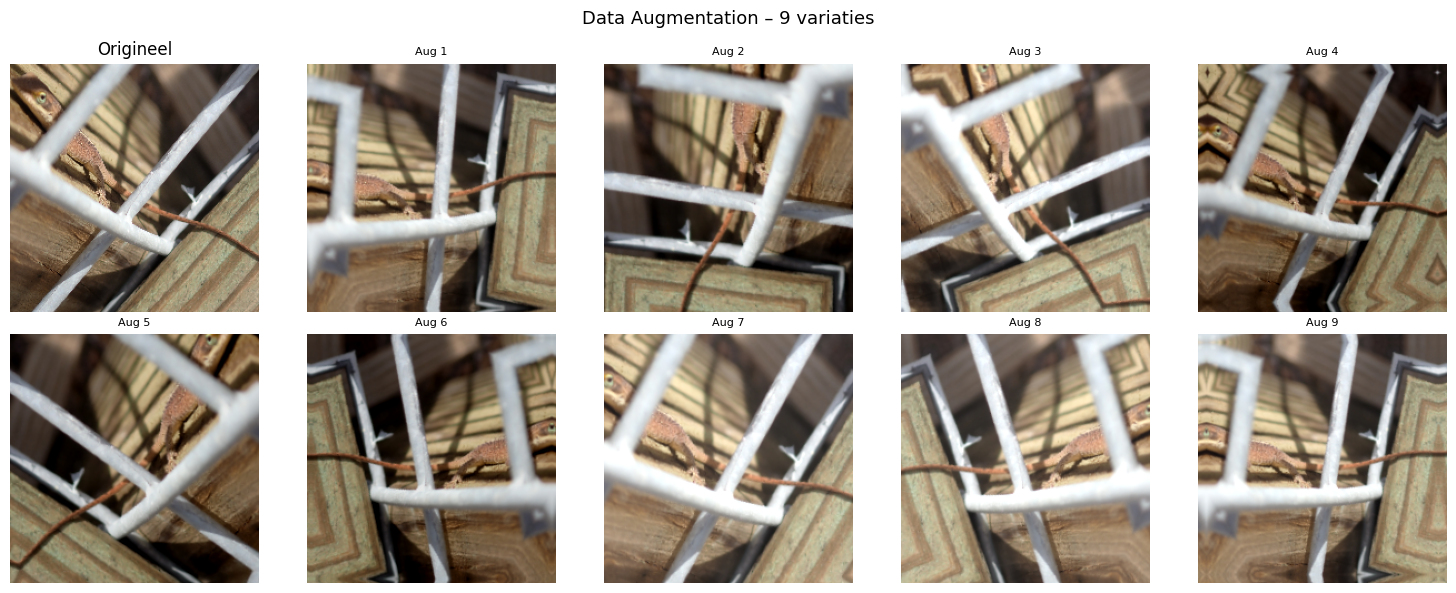

In [19]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
    layers.RandomBrightness(0.10),
], name='data_augmentation')

# Visualisatie van augmentatie
for images, labels in train_ds.take(1):
    sample_img = images[0]
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes[0,0].imshow(sample_img.numpy().astype('uint8'))
    axes[0,0].set_title('Origineel'); axes[0,0].axis('off')
    for i, ax in enumerate(axes.flatten()[1:]):
        aug = data_augmentation(tf.expand_dims(sample_img, 0))[0]
        ax.imshow(aug.numpy().astype('uint8'))
        ax.set_title(f'Aug {i+1}', fontsize=8); ax.axis('off')
    plt.suptitle('Data Augmentation – 9 variaties', fontsize=13)
    plt.tight_layout(); plt.show()

In [20]:
# Prefetch voor snelheid
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

---
## 3. Eigen CNN Model (Baseline)

In [21]:
own_model = models.Sequential([
    layers.Input(shape=(*IMAGE_SIZE, 3)),
    layers.Rescaling(1./255),
    data_augmentation,

    layers.Conv2D(32,  (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.2),

    layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.3),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),       
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='eigen_cnn')

own_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
own_model.summary()

Model: "eigen_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,084,551 (99.50 MB)

 Trainable params: 26,083,591 (99.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [22]:
history_own = own_model.fit(
    train_ds, validation_data=val_ds, epochs=20
)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.1451 - loss: 25.0796 - val_accuracy: 0.1316 - val_loss: 8.0548
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.1470 - loss: 2.8488 - val_accuracy: 0.1241 - val_loss: 6.6576
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.1517 - loss: 1.9458 - val_accuracy: 0.1541 - val_loss: 5.9520
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.1320 - loss: 1.9527 - val_accuracy: 0.1692 - val_loss: 5.7184
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.1414 - loss: 1.9481 - val_accuracy: 0.1541 - val_loss: 5.4216
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.1564 - loss: 1.9668 - val_accuracy: 0.1729 - val_loss: 10.1914
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.1395 - loss: 1.9462 - val_accuracy: 0.1692 - val_loss: 8.8450
Epoch 8/20
22/34 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.1648 - loss: 1.9457

KeyboardInterrupt: 

---
## 4. Trainingscurves

In [23]:
def plot_training(history, title='Trainingscurves'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['loss'],     label='Training',   color='steelblue')
    ax1.plot(history.history['val_loss'], label='Validatie',  color='orange')
    ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['accuracy'],     label='Training',  color='steelblue')
    ax2.plot(history.history['val_accuracy'], label='Validatie', color='orange')
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout(); plt.show()
    print(f'Beste validatie-accuracy: {max(history.history["val_accuracy"]):.4f}')

plot_training(history_own, 'Eigen CNN – Trainingscurves')

NameError: name 'history_own' is not defined

---
## 5. Transfer Learning – EfficientNetB0

**Fase 1:** base bevroren, enkel eigen hoofd trainen  
**Fase 2:** fine-tuning – laatste lagen ontdooien met lage learning rate

In [24]:
# EfficientNet preprocessing (geen Rescaling nodig)
def preprocess_eff(image, label):
    return eff_preprocess(tf.cast(image, tf.float32)), label

train_ds_eff = train_ds.map(preprocess_eff, num_parallel_calls=AUTOTUNE)
val_ds_eff   = val_ds.map(preprocess_eff,   num_parallel_calls=AUTOTUNE)

# Base model laden
base_model = EfficientNetB0(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False
print(f'EfficientNetB0: {len(base_model.layers)} lagen, bevroren')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB0: 238 lagen, bevroren


In [25]:
# Eigen hoofd bouwen
inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = tf.keras.Model(inputs, outputs, name='efficientnet_transfer')
tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
tl_model.summary()

Model: "efficientnet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,426 (16.73 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

--- Fase 1: hoofd trainen (base bevroren) ---
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 408ms/step - accuracy: 0.4185 - loss: 1.8622 - val_accuracy: 0.5789 - val_loss: 1.1591
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 355ms/step - accuracy: 0.6320 - loss: 1.0839 - val_accuracy: 0.5977 - val_loss: 1.0953
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 355ms/step - accuracy: 0.7125 - loss: 0.8122 - val_accuracy: 0.6165 - val_loss: 0.9764
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 352ms/step - accuracy: 0.7341 - loss: 0.7282 - val_accuracy: 0.6053 - val_loss: 0.9538
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 352ms/step - accuracy: 0.7912 - loss: 0.6154 - val_accuracy: 0.6278 - val_loss: 0.9200
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 349ms/step - accuracy: 0.7959 - loss: 0.5276 - val_accuracy: 0.6353 - val_loss: 0.9216
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 357ms/step - accuracy: 0.8427 - loss: 0.4615 - val_accuracy: 0.6541 - val_loss: 0.9296
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 346ms/ste

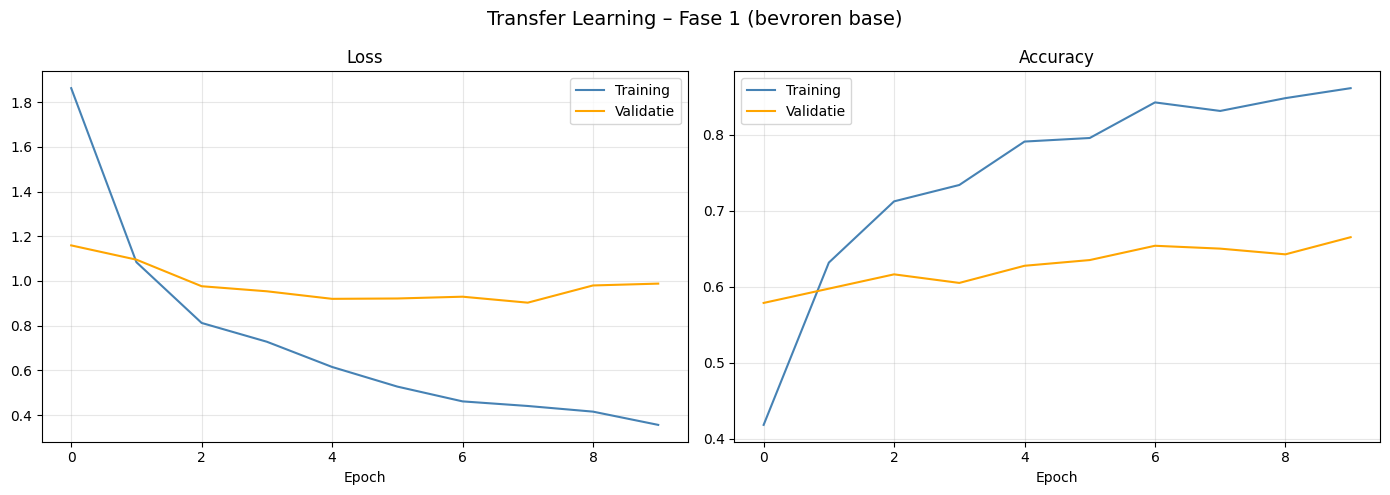

Beste validatie-accuracy: 0.6654
Fase 1 model opgeslagen!


In [26]:
# Fase 1: hoofd trainen
print('--- Fase 1: hoofd trainen (base bevroren) ---')
history_tl = tl_model.fit(
    train_ds_eff, validation_data=val_ds_eff, epochs=10
)
plot_training(history_tl, 'Transfer Learning – Fase 1 (bevroren base)')

tl_model.save('best_model_fase1.keras')
print("Fase 1 model opgeslagen!")

Fine-tuning: 38 van 238 lagen trainbaar
--- Fase 2: fine-tuning ---
Epoch 1/10


34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 479ms/step - accuracy: 0.7172 - loss: 0.7533 - val_accuracy: 0.6579 - val_loss: 1.0759
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 15s 434ms/step - accuracy: 0.7313 - loss: 0.7528 - val_accuracy: 0.6429 - val_loss: 1.1376
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 425ms/step - accuracy: 0.7425 - loss: 0.7251 - val_accuracy: 0.6353 - val_loss: 1.1697
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 427ms/step - accuracy: 0.7416 - loss: 0.6755 - val_accuracy: 0.6353 - val_loss: 1.1924
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 426ms/step - accuracy: 0.7743 - loss: 0.6516 - val_accuracy: 0.6316 - val_loss: 1.1958
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 493ms/step - accuracy: 0.7875 - loss: 0.6066 - val_accuracy: 0.6278 - val_loss: 1.1959
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 513ms/step - accuracy: 0.7659 - loss: 0.6396 - val_accuracy: 0.6241 - val_loss: 1.1978
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 465ms/step - accuracy: 0.7725 - loss: 0.6030 - val_accuracy: 0.620

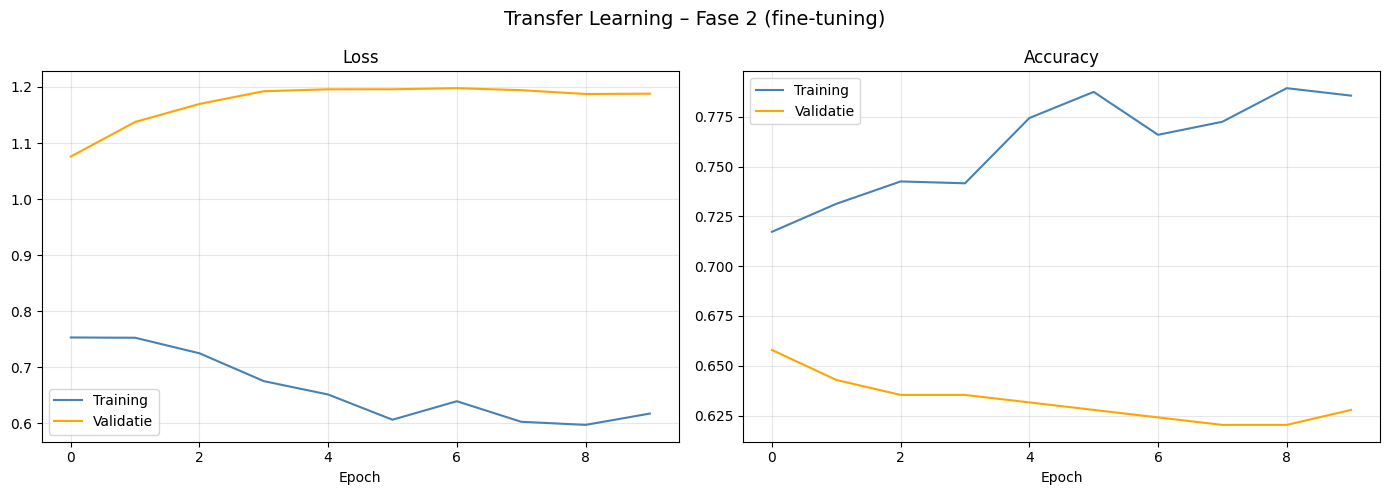

Beste validatie-accuracy: 0.6579


In [27]:
# Fase 2: fine-tuning
base_model.trainable = True
fine_tune_at = 200
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f'Fine-tuning: {sum(l.trainable for l in base_model.layers)} van {len(base_model.layers)} lagen trainbaar')

tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # lagere LR voor fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('--- Fase 2: fine-tuning ---')
history_ft = tl_model.fit(
    train_ds_eff, validation_data=val_ds_eff, epochs=10
)
plot_training(history_ft, 'Transfer Learning – Fase 2 (fine-tuning)')

---
## 6. Evaluatie & Confusion Matrix

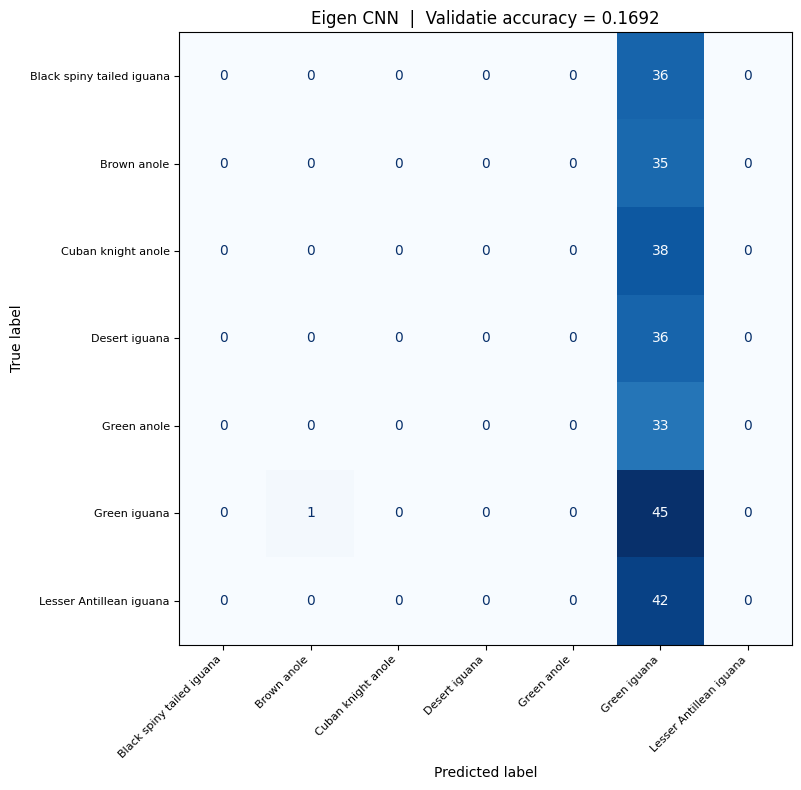


Classification Report – Eigen CNN
              precision    recall  f1-score   support

       Black       0.00      0.00      0.00        36
       Brown       0.00      0.00      0.00        35
       Cuban       0.00      0.00      0.00        38
      Desert       0.00      0.00      0.00        36
       Green       0.00      0.00      0.00        33
       Green       0.17      0.98      0.29        46
      Lesser       0.00      0.00      0.00        42

    accuracy                           0.17       266
   macro avg       0.02      0.14      0.04       266
weighted avg       0.03      0.17      0.05       266



c:\Users\jefco\Documents\AI\DL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jefco\Documents\AI\DL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jefco\Documents\AI\DL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

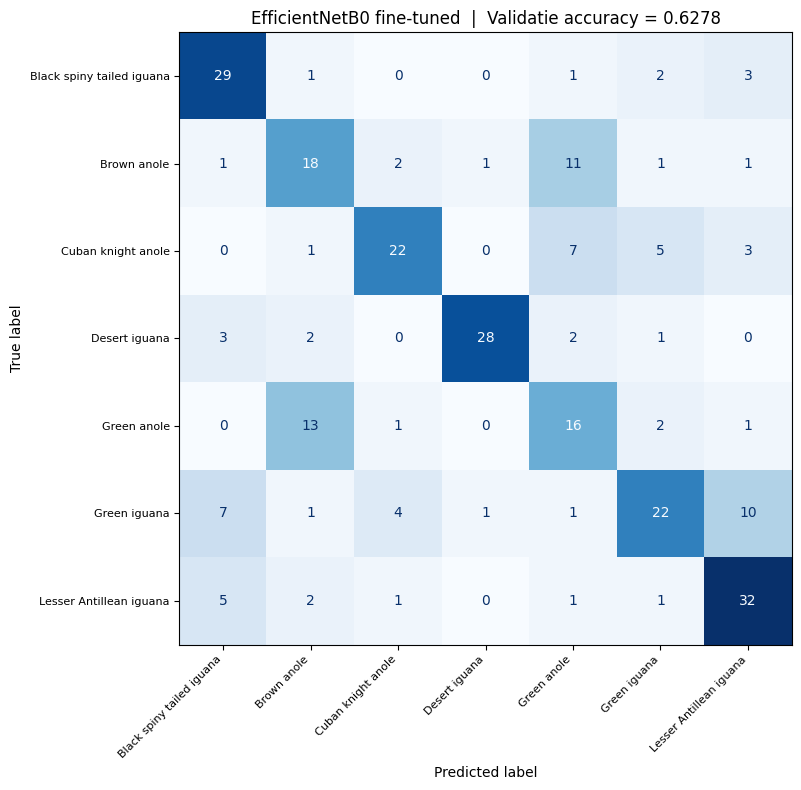


Classification Report – EfficientNetB0 fine-tuned
              precision    recall  f1-score   support

       Black       0.64      0.81      0.72        36
       Brown       0.47      0.51      0.49        35
       Cuban       0.73      0.58      0.65        38
      Desert       0.93      0.78      0.85        36
       Green       0.41      0.48      0.44        33
       Green       0.65      0.48      0.55        46
      Lesser       0.64      0.76      0.70        42

    accuracy                           0.63       266
   macro avg       0.64      0.63      0.63       266
weighted avg       0.64      0.63      0.63       266


SAMENVATTING
  Eigen CNN          : 0.1692
  Transfer Learning  : 0.6278
  Beste model        : EfficientNetB0


In [28]:
def evaluate_model(model, dataset, title='Model'):
    all_labels, all_preds = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_preds.extend(np.argmax(preds, axis=1))
        all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    cm  = confusion_matrix(all_labels, all_preds)
    short = [c.replace('_', ' ') for c in CLASS_NAMES]

    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay(cm, display_labels=short).plot(
        cmap=plt.cm.Blues, ax=ax, colorbar=False
    )
    ax.set_title(f'{title}  |  Validatie accuracy = {acc:.4f}', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout(); plt.show()

    abbrev = [c.split('_')[0][:8] for c in CLASS_NAMES]
    print(f'\nClassification Report – {title}')
    print(classification_report(all_labels, all_preds, target_names=abbrev))
    return acc

print('='*55)
acc_own = evaluate_model(own_model, val_ds,     title='Eigen CNN')
print('='*55)
acc_tl  = evaluate_model(tl_model,  val_ds_eff, title='EfficientNetB0 fine-tuned')

print('\nSAMENVATTING')
print(f'  Eigen CNN          : {acc_own:.4f}')
print(f'  Transfer Learning  : {acc_tl:.4f}')
print(f'  Beste model        : {"EfficientNetB0" if acc_tl > acc_own else "Eigen CNN"}')

---
## 7. Kaggle Submission

Testset: 326 afbeeldingen, genummerd `1.jpg` t/m `326.jpg`.  
Submission formaat: `id,label` (zie `sample_submission.csv`).

In [29]:
test_csv = pd.read_csv('test.csv')
test_ids = test_csv['id'].tolist()
print(f'Testset: {len(test_ids)} afbeeldingen (id {test_ids[0]} t/m {test_ids[-1]})')

Testset: 326 afbeeldingen (id 1 t/m 326)


In [30]:
# Testafbeeldingen laden in volgorde van de IDs
X_test = []
for img_id in test_ids:
    img = tf.keras.utils.load_img(
        os.path.join(TEST_DIR, f'{img_id}.jpg'),
        target_size=IMAGE_SIZE
    )
    X_test.append(tf.keras.utils.img_to_array(img))

X_test = np.array(X_test)
print(f'Test array: {X_test.shape}')

Test array: (326, 224, 224, 3)


In [31]:
# Preprocessing + voorspellingen
X_test_eff  = eff_preprocess(X_test.astype('float32'))
predictions = tl_model.predict(X_test_eff, batch_size=BATCH_SIZE, verbose=1)
pred_labels = np.argmax(predictions, axis=1)

print('Verdeling voorspellingen:')
for cls_id, cnt in zip(*np.unique(pred_labels, return_counts=True)):
    print(f'  {cls_id} – {CLASS_NAMES[cls_id]}: {cnt}')

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 248ms/step
Verdeling voorspellingen:
  0 – Black_spiny_tailed_iguana: 52
  1 – Brown_anole: 47
  2 – Cuban_knight_anole: 37
  3 – Desert_iguana: 52
  4 – Green_anole: 45
  5 – Green_iguana: 38
  6 – Lesser_Antillean_iguana: 55


In [32]:
# Submission aanmaken
submission = pd.DataFrame({'id': test_ids, 'label': pred_labels})
submission.to_csv('submission.csv', index=False)
print('submission.csv opgeslagen!')
submission.head(10)

submission.csv opgeslagen!


,id,label
0,1,3
1,2,5
2,3,0
3,4,0
4,5,0
5,6,4
6,7,6
7,8,4
8,9,6
9,10,1


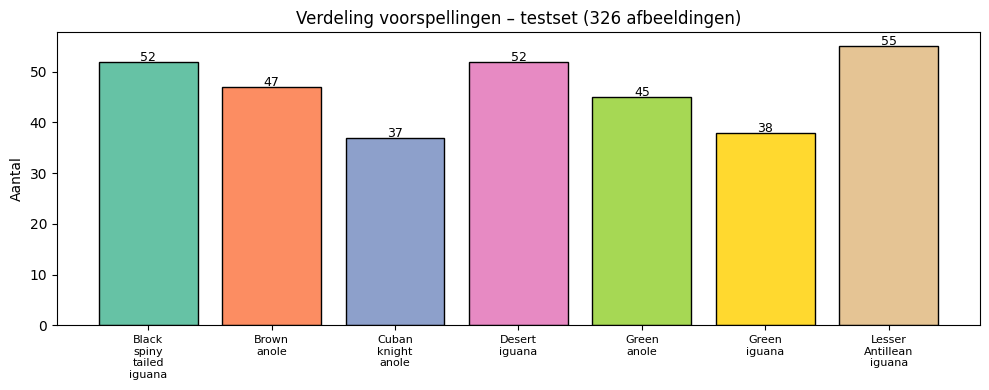

In [33]:
# Verdeling visualiseren
pred_counts = pd.Series(pred_labels).map(dict(enumerate(CLASS_NAMES))).value_counts().reindex(CLASS_NAMES)
plt.figure(figsize=(10, 4))
plt.bar(range(NUM_CLASSES), pred_counts.values, color=plt.cm.Set2.colors, edgecolor='black')
plt.xticks(range(NUM_CLASSES), [c.replace('_', '\n') for c in CLASS_NAMES], fontsize=8)
plt.title('Verdeling voorspellingen – testset (326 afbeeldingen)')
plt.ylabel('Aantal')
for i, v in enumerate(pred_counts.values):
    plt.text(i, v + 0.2, str(v), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

In [34]:
# Model opslaan
tl_model.save('lizard_model.keras')
print('Model opgeslagen als lizard_model.keras')

Model opgeslagen als lizard_model.keras


---
## 8. GenAI Policy

**Welk AI-tool hebben we gebruikt?**  
_[bv. Claude, ChatGPT, ...]_

**Waarvoor hebben we het gebruikt?**  
_[bv. structuur van het notebook, uitleg van functies, debugging]_

**Welke prompts hebben we gebruikt?**  
_[voeg hier de prompts in]_

**Beperkingen en onzekerheden:**  
_[bv. we hebben alle code zelf begrepen en getest voor indiening]_